In [3]:
import numpy as np
from numpy import sin, pi, exp
import matplotlib.pyplot as plt

# generate support data files for tutorial Southern Ocean Reentrant Channel
# hard-coded for eddying resolution: dx=dy=5 km (Cartesian)
# to exactly match the bathymetry and forcing in the coarse-res setup

# grid depths generated Using the hyperbolic tangent method of 
# Stewart et al. (2017) DOI: 10.1016/j.ocemod.2017.03.012
# to design an optimal grid.
# https://github.com/kialstewart/vertical_grid_for_ocean_models

dr = np.array([5.48716549,   6.19462098,   6.99291201,   7.89353689, \
               8.90937723,  10.05483267,  11.34595414,  12.80056778, \
              14.43837763,  16.28102917,  18.35210877,  20.67704362, \
              23.28285446,  26.1976981 ,  29.45012046,  33.06792588, \
              37.07656002,  41.496912  ,  46.34247864,  51.61592052, \
              57.30518684,  63.37960847,  69.78661289,  76.44996107, \
              83.27047568,  90.13003112,  96.89898027, 103.44631852, \
             109.65099217, 115.4122275 , 120.65692923, 125.34295968, \
             129.45821977, 133.01641219, 136.05088105, 138.60793752, \
             140.74074276, 142.50436556, 143.95220912, 145.133724  , \
             146.09317287, 146.86917206, 147.49475454, 147.99774783, \
             148.40131516, 148.72455653, 148.98310489, 149.18968055, \
             149.35458582])
nx = 600
ny = 1200
nr = len(dr)
rF = (np.insert(np.cumsum(dr), 0, 0)) # z-coordinates of vertical cell faces
z = np.diff(rF)/2 + rF[:-1]           # z-coordinates of vertical cell centers
H = -np.sum(dr)                       # max depth of vertical grid

# bathymetry -- flat bottom of depth H (m) with idealized mid-depth ridge
bump_max = 2000.   # peak height of ridge above flat bottom depth
bathy = H * np.ones([ny, nx])
bump=np.zeros([ny, nx])
# sinusoidal bump running N-S through middle of domain
# this is hard-coded for nx=200, ny=400 resolution
r1 = bump_max * sin(np.linspace(0,pi,310))
r2 = np.reshape((np.linspace(0,1,304)), [304,1])  # create linear ramp for center notch
bump[:,130:440] = r1
# linearly lower bump height toward center notch
bump[268:572,:] = bump[268:572,:] * np.flip(r2[:])
bump[608:912,:] = bump[608:912,:] * r2[:]
bump[571:609,:] = 0.0  # notch; in these latitude bands, contours of f/H are unblocked
bathy = bathy + bump;
bathy[0:10,:] = 0.                    # wall at southern boundary, matching coarse-res
bathy.astype('>f4').tofile('bathy.5km.bin')
print(bump.shape)

(1200, 600)


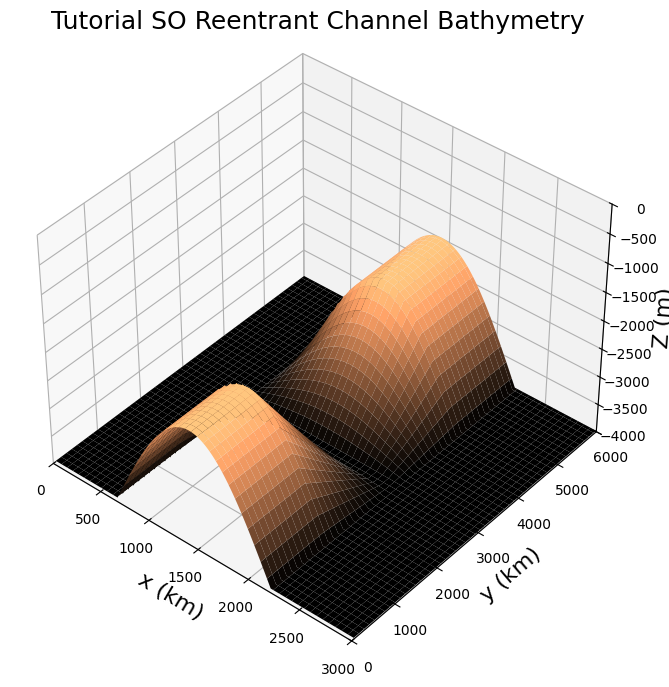

In [4]:
#plot bathymetry as 3D surface plot, as shown in fig 4.10
XC_1km = np.linspace(2500, 5997500, 1200)
YC_1km = np.linspace(2500, 2997500, 600)
YC,XC = np.meshgrid(YC_1km,XC_1km)
plt.figure(figsize=(10,8)) 
ax = plt.axes(projection='3d')
ax.plot_surface(YC[10:,:]/1000,XC[10:,:]/1000, bathy[10:,:], cmap='copper', edgecolor='none');
ax.view_init(40, -50)
ax.set_zlim(-4000,0)
ax.set_zlabel('Z (m)', fontsize=16)
ax.set_title('Tutorial SO Reentrant Channel Bathymetry', fontsize=18)
plt.xlabel('x (km)',fontsize=16); plt.ylabel('y (km)', fontsize=16)
plt.xlim(0,3000)
plt.ylim(0,6000);

In [5]:
# Vertical interfaces (z_w) and centers (z_c), z<0 downward
z_w = np.concatenate(([0.0], -np.cumsum(dr)))        # interfaces: 0, -5.4, ...
z_c = 0.5 * (z_w[:-1] + z_w[1:])                       # cell centers
depth = -z_c                                           # positive downward
H = depth[-1]                                          # total depth (m)

# ----------------------------
# Meridional coordinate (y) for shaping profiles
# ----------------------------
# y index 0 = "south", ny-1 = "north"
j = np.arange(ny)
j_norm = j / (ny - 1.0)    # 0 (south) → 1 (north)

# You can think of j_norm ~ latitude-like coordinate.

# ----------------------------
# Surface T, S profiles (SST, SSS)
# ----------------------------
# Rough Southern-Ocean-flavored values:
# South: cold (-1.5 C), fresh-ish (33.8)
# North: warmer (8 C), saltier (35.3)

T_south = -1.0
T_north =  6.0
S_south = 34.0
S_north = 35.0

# Use a smooth tanh-like transition instead of perfectly linear
def smooth_meridional_profile(val_south, val_north, j_norm, sharpness=6.0):
    """Sigmoidal transition from south to north."""
    # center the transition around mid-channel
    xi = (j_norm - 0.5) * sharpness
    w = 0.5 * (1.0 + np.tanh(xi))   # goes from 0 to 1
    return val_south * (1 - w) + val_north * w

T_surf = smooth_meridional_profile(T_south, T_north, j_norm, sharpness=5.0)  # (ny,)
S_surf = smooth_meridional_profile(S_south, S_north, j_norm, sharpness=5.0)  # (ny,)

# ----------------------------
# Mixed layer depth profile MLD(y)
# ----------------------------
# Southern Ocean-ish:
# Deep mixed layers in south (200-300 m), shallower north (50-80 m)
MLD_south = 250.0  # m
MLD_north =  60.0  # m
MLD = smooth_meridional_profile(MLD_south, MLD_north, j_norm, sharpness=4.0)  # (ny,)

# ----------------------------
# Deep water T, S and vertical decay scales
# ----------------------------
# Deep ACC waters: cold ~0.5 C, salty-ish ~34.7
T_deep = 0.5
S_deep = 34.7

h_T = 700.0   # e-folding scale for T below MLD (m)
h_S = 1000.0  # e-folding scale for S below MLD (m)

# ----------------------------
# Build 3D T and S fields
# ----------------------------
depth_3d   = depth[:, None, None]      # (nr,1,1)
MLD_3d     = MLD[None, :, None]        # (1,ny,1)
T_surf_3d  = T_surf[None, :, None]     # (1,ny,1)
S_surf_3d  = S_surf[None, :, None]     # (1,ny,1)

above_mld = depth_3d <= MLD_3d         # (nr,ny,1)
dz_below  = np.maximum(depth_3d - MLD_3d, 0.0)

# Below-MLD profiles toward deep values
T_below = T_deep + (T_surf_3d - T_deep) * np.exp(-dz_below / h_T)
S_below = S_deep + (S_surf_3d - S_deep) * np.exp(-dz_below / h_S)

# Combine: if above MLD -> surface value, else -> exponential profile
T_kj1 = np.where(above_mld, T_surf_3d, T_below)  # (nr,ny,1)
S_kj1 = np.where(above_mld, S_surf_3d, S_below)  # (nr,ny,1)

# Now replicate in x (zonal) – copy across all longitudes
T_3D = np.repeat(T_kj1, nx, axis=2)              # (nr,ny,nx)
S_3D = np.repeat(S_kj1, nx, axis=2)              # (nr,ny,nx)

# Now replicate in x (zonal) – just copy across all longitudes
T_3D = np.repeat(T_3D[:, :, :1], nx, axis=2)
S_3D = np.repeat(S_3D[:, :, :1], nx, axis=2)

# ----------------------------
# RBCS masks (sponge layer at the north)
# ----------------------------
rbcs_mask_T = np.zeros((nr, ny, nx), dtype="float64")
rbcs_mask_S = np.zeros((nr, ny, nx), dtype="float64")

# no restoring in top cell (k=0), core model handles SST/SSS restoring
j_strong = 10   # last 10 grid rows: strong sponge
j_weak   = 20   # last 20 grid rows: weak sponge transition

# Strong sponge in northernmost 10 grid rows, below surface:
rbcs_mask_T[1:, -j_strong:, :] = 1.0
rbcs_mask_S[1:, -j_strong:, :] = 1.0

# Weaker sponge in next 10 grid rows:
rbcs_mask_T[1:, -j_weak:-j_strong, :] = 0.25
rbcs_mask_S[1:, -j_weak:-j_strong, :] = 0.25

# ----------------------------
# Write to binary files (big-endian float32)
# ----------------------------
T_3D.astype(">f4").tofile("temperature.5km.bin")
S_3D.astype(">f4").tofile("salinity.5km.bin")

# Surface restoring fields (SST/SSS) at C-points: 2D (ny, nx)
SST_relax = np.repeat(T_surf[:, None], nx, axis=1)   # (ny,nx)
SSS_relax = np.repeat(S_surf[:, None], nx, axis=1)

SST_relax.astype(">f4").tofile("SST_relax.5km.bin")
SSS_relax.astype(">f4").tofile("SSS_relax.5km.bin")

# RBCS masks:
rbcs_mask_T.astype(">f4").tofile("T_relax_mask.5km.bin")
rbcs_mask_S.astype(">f4").tofile("S_relax_mask.5km.bin")

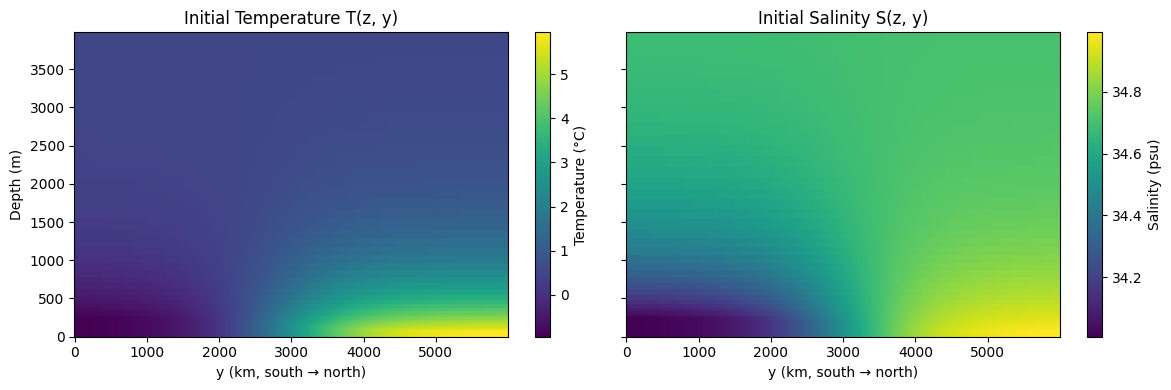

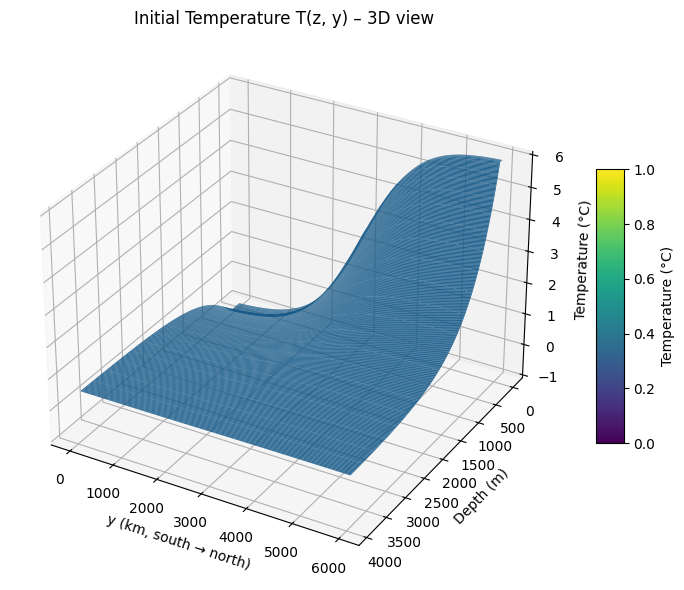

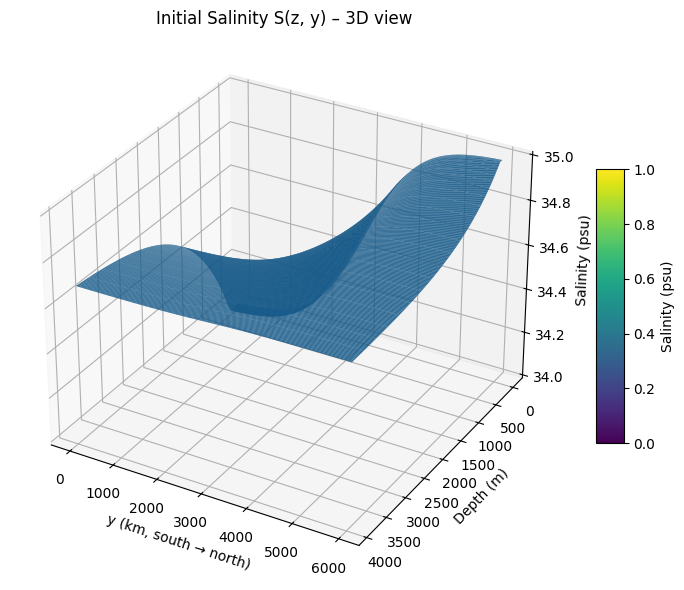

In [6]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (needed for 3D)

# ==========================================================
# 1) Rebuild physical coordinates from your vertical grid
# ==========================================================
# dr: (nr,) layer thicknesses, already defined above
nr = len(dr)

# Vertical faces (0 at surface, positive downward)
z_faces = np.concatenate(([0.0], np.cumsum(dr)))   # (nr+1,)
# Vertical centers
z_centers = 0.5 * (z_faces[:-1] + z_faces[1:])     # (nr,)
depth = z_centers                                  # depth > 0 downward, in meters

# Meridional coordinate (index j = 0..ny-1)
j = np.arange(ny)

# If you want a physical y in km (5 km grid spacing):
dy = 5_000.0                   # 5 km in meters
y = j * dy                     # y in meters
y_km = y / 1000.0              # y in km

# Take a single longitude section (they are all the same initially)
T_sec = T_3D[:, :, 0]          # shape (nr, ny)
S_sec = S_3D[:, :, 0]

# Make 2D coordinate grids for plotting
Y2D, Z2D = np.meshgrid(y_km, depth)   # (nr, ny) each

# ==========================================================
# 2) 2D sections: T(z,y) and S(z,y) with same axes
# ==========================================================
fig, axs = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

# Temperature section
im0 = axs[0].pcolormesh(y_km, depth, T_sec, shading="auto")
axs[0].invert_yaxis()  # surface at top
axs[0].set_xlabel("y (km, south → north)")
axs[0].set_ylabel("Depth (m)")
axs[0].set_title("Initial Temperature T(z, y)")
cbar0 = fig.colorbar(im0, ax=axs[0])
cbar0.set_label("Temperature (°C)")

# Salinity section
im1 = axs[1].pcolormesh(y_km, depth, S_sec, shading="auto")
axs[1].invert_yaxis()
axs[1].set_xlabel("y (km, south → north)")
axs[1].set_title("Initial Salinity S(z, y)")
cbar1 = fig.colorbar(im1, ax=axs[1])
cbar1.set_label("Salinity (psu)")

plt.tight_layout()
plt.show()

# ==========================================================
# 3) 3D surface plots: T(z,y) and S(z,y)
#    (same y/depth scales, T/S as surface height)
# ==========================================================

# 3D Temperature surface
fig_T = plt.figure(figsize=(8, 6))
ax_T = fig_T.add_subplot(111, projection="3d")

surf_T = ax_T.plot_surface(
    Y2D, depth[:, None] * np.ones_like(Y2D),
    T_sec,
    rstride=2, cstride=4,
    linewidth=0, antialiased=True
)

ax_T.set_xlabel("y (km, south → north)")
ax_T.set_ylabel("Depth (m)")
ax_T.set_zlabel("Temperature (°C)")
ax_T.set_title("Initial Temperature T(z, y) – 3D view")
ax_T.invert_yaxis()  # so 0 m at top

fig_T.colorbar(surf_T, shrink=0.5, aspect=10, label="Temperature (°C)")
plt.tight_layout()
plt.show()

# 3D Salinity surface
fig_S = plt.figure(figsize=(8, 6))
ax_S = fig_S.add_subplot(111, projection="3d")

surf_S = ax_S.plot_surface(
    Y2D, depth[:, None] * np.ones_like(Y2D),
    S_sec,
    rstride=2, cstride=4,
    linewidth=0, antialiased=True
)

ax_S.set_xlabel("y (km, south → north)")
ax_S.set_ylabel("Depth (m)")
ax_S.set_zlabel("Salinity (psu)")
ax_S.set_title("Initial Salinity S(z, y) – 3D view")
ax_S.invert_yaxis()

fig_S.colorbar(surf_S, shrink=0.5, aspect=10, label="Salinity (psu)")
plt.tight_layout()
plt.show()


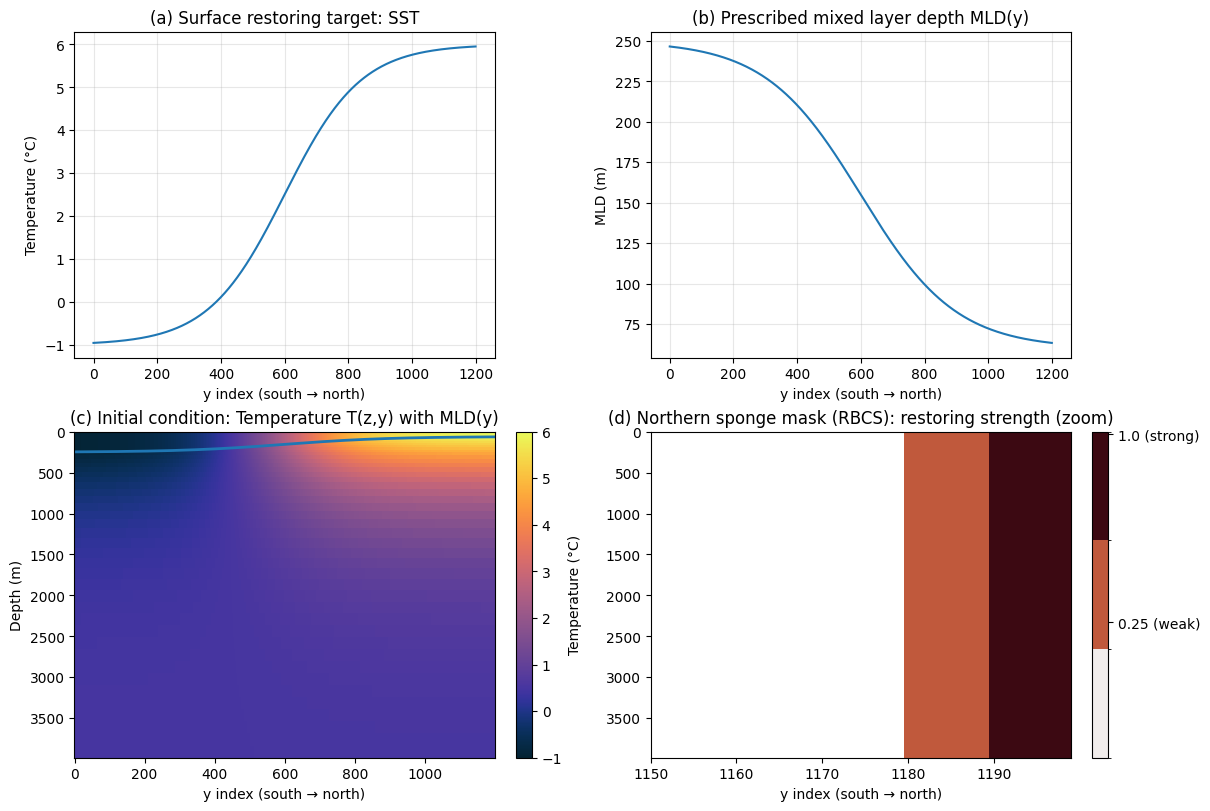

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import cmocean.cm as cmo

# ---- assumptions: these exist from your script ----
# T_3D: (nr, ny, nx)
# S_3D: (nr, ny, nx)
# T_surf: (ny,)
# S_surf: (ny,)
# MLD:    (ny,)
# depth:  (nr,) positive downward
# rbcs_mask_T: (nr, ny, nx)

ny = T_3D.shape[1]
nx = T_3D.shape[2]
nr = T_3D.shape[0]

# Use physical y if you know dy (meters). If not, leave as index.
# dy_m = 5000.0
# y = np.arange(ny) * dy_m / 1000.0   # km
# y_label = "y (km)"
y = np.arange(ny)
y_label = "y index (south → north)"

z = depth  # m, positive downward

# Pick an x-slice (since fields are zonally uniform initially, x=0 is fine)
T_sec = T_3D[:, :, 0]           # (nr, ny)
S_sec = S_3D[:, :, 0]
mask_sec = rbcs_mask_T[:, :, 0] # (nr, ny)

# Create mesh for pcolormesh
Y, Z = np.meshgrid(y, z)

fig, axs = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

# (a) Surface restoring targets
ax = axs[0, 0]
ax.plot(y, T_surf, label="SST target")
ax.set_xlabel(y_label)
ax.set_ylabel("Temperature (°C)")
ax.set_title("(a) Surface restoring target: SST")
ax.grid(True, alpha=0.3)

# (b) Mixed layer depth profile
ax = axs[0, 1]
ax.plot(y, MLD)
ax.set_xlabel(y_label)
ax.set_ylabel("MLD (m)")
ax.set_title("(b) Prescribed mixed layer depth MLD(y)")
ax.grid(True, alpha=0.3)

# (c) Initial temperature section + MLD overlay
ax = axs[1, 0]
pcm = ax.pcolormesh(Y, Z, T_sec, shading="auto",
                    cmap=cmo.thermal, vmin=-1.0, vmax=6.0)
ax.plot(y, MLD, linewidth=2)  # overlay MLD line
ax.invert_yaxis()
ax.set_xlabel(y_label)
ax.set_ylabel("Depth (m)")
ax.set_title("(c) Initial condition: Temperature T(z,y) with MLD(y)")
cbar = fig.colorbar(pcm, ax=ax)
cbar.set_label("Temperature (°C)")

# (d) Sponge mask (where subsurface restoring is applied)
import numpy as np
import matplotlib.pyplot as plt
import cmocean.cm as cmo
import matplotlib.colors as colors

mask_plot = np.ma.masked_where(mask_sec == 0.0, mask_sec)

cmap = cmo.amp.copy()         # any perceptual cmap is fine
cmap.set_bad("white")         # make the masked (zero) area white

# since your mask has discrete values (0, 0.25, 1.0), use discrete bins
bounds = [0.0, 0.125, 0.625, 1.01]   # splits: 0–0.125, 0.125–0.625, 0.625–1.01
norm = colors.BoundaryNorm(bounds, cmap.N)
ax = axs[1, 1]
pcm2 = ax.pcolormesh(Y, Z, mask_plot, shading="auto", cmap=cmap, norm=norm)
ax.set_xlim(y[-50], y[-1])
ax.set_title("(d) Northern sponge mask (RBCS): restoring strength (zoom)")
ax.invert_yaxis()
ax.set_xlabel(y_label)
cbar2 = fig.colorbar(pcm2, ax=ax)
cbar2.set_ticks([0.25, 1.0])
cbar2.set_ticklabels(["0.25 (weak)", "1.0 (strong)"])

plt.show()